# Strategy Backtesting

In this notebook, we simulate the historical performance of the volatility-adaptive trading framework.

Objectives:
1. Evaluate portfolio growth
2. Compare against buy-and-hold
3. Analyze drawdowns
4. Examine adaptive exposure behavior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv(
    "../data/SP500_processed.csv",
    index_col="Date",
    parse_dates=True
)

In [3]:
sp500["rolling_vol"] = (
    sp500["log_return"]
    .rolling(30)
    .std()
)

In [4]:
low_threshold = sp500["rolling_vol"].quantile(0.33)

high_threshold = sp500["rolling_vol"].quantile(0.66)

In [5]:
conditions = [
    sp500["rolling_vol"] <= low_threshold,
    
    sp500["rolling_vol"] <= high_threshold
]

choices = [
    1.0,
    0.5
]

sp500["position_size"] = np.select(
    conditions,
    choices,
    default=0.2
)

In [6]:
sp500["strategy_return"] = (
    sp500["position_size"].shift(1)
    * sp500["log_return"]
)

In [7]:
initial_capital = 100

In [8]:
sp500["portfolio_value"] = (
    initial_capital
    * (1 + sp500["strategy_return"]).cumprod()
)

sp500["market_value"] = (
    initial_capital
    * (1 + sp500["log_return"]).cumprod()
)

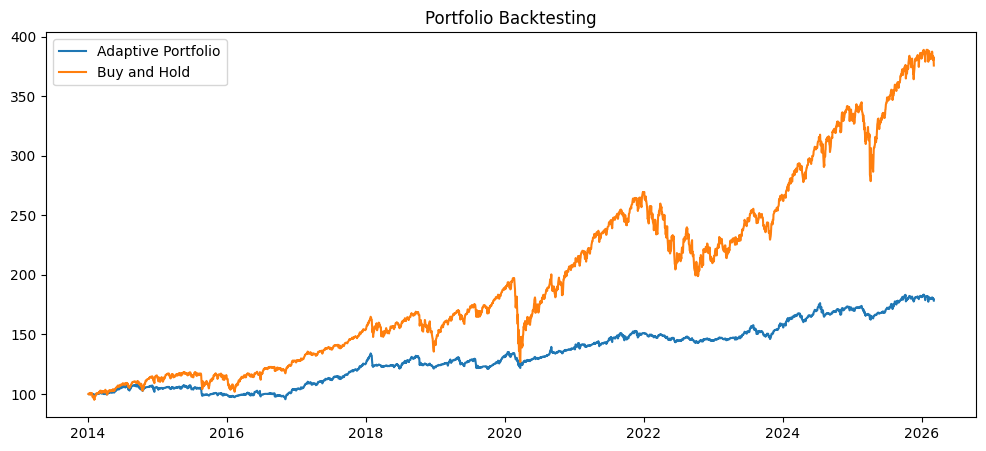

In [9]:
plt.figure(figsize=(12,5))

plt.plot(
    sp500["portfolio_value"],
    label="Adaptive Portfolio"
)

plt.plot(
    sp500["market_value"],
    label="Buy and Hold"
)

plt.legend()

plt.title("Portfolio Backtesting")

plt.show()

In [10]:
rolling_peak = (
    sp500["portfolio_value"]
    .cummax()
)

drawdown = (
    sp500["portfolio_value"]
    - rolling_peak
) / rolling_peak

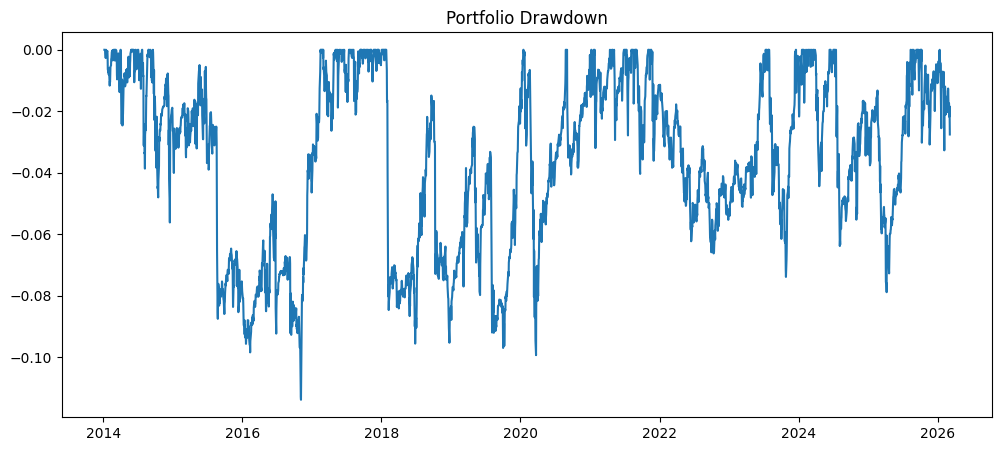

In [11]:
plt.figure(figsize=(12,5))

plt.plot(drawdown)

plt.title("Portfolio Drawdown")

plt.show()

## Backtesting Interpretation

The adaptive framework attempts to preserve capital during periods of elevated volatility by dynamically reducing exposure.

This may reduce severe drawdowns during unstable market conditions.

# Conclusion

Backtesting demonstrates how volatility-adaptive exposure can improve portfolio stability during turbulent market periods while maintaining market participation during stable conditions.

## Portfolio Growth Interpretation

The strategy dynamically adjusts exposure during volatile periods.

This may reduce downside losses during crises while maintaining participation during stable market conditions.

## Drawdown Interpretation

The strategy attempts to preserve capital during periods of elevated volatility.

Reduced drawdowns suggest improved downside protection compared to fully exposed market participation.